# Working with Populations of Mechanisms

When designing linkages, you rarely work with one mechanism at a time.
The typical workflow is:

1. **Define** a topology or synthesis problem
2. **Generate** many candidate mechanisms (via optimization or synthesis)
3. **Simulate** them all
4. **Filter and rank** by quality metrics
5. **Visualize** the best candidates

Pylinkage provides three abstractions that make this workflow seamless:

- **`Member`** -- a single mechanism variant (dimensions + scores + trajectory)
- **`Ensemble`** -- N parameter variants of one topology (batch simulation, numpy-style indexing)
- **`Population`** -- a heterogeneous collection of mechanisms (different topologies)

This notebook walks through all three, from optimization to synthesis to visualization.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", category=DeprecationWarning)

## Part A: Optimization → Ensemble

Optimizers now return an `Ensemble` directly. Let's optimize a four-bar
linkage with PSO and explore the result.

In [2]:
from pylinkage.optimization import (
    generate_bounds,
    particle_swarm_optimization,
    trials_and_errors_optimization,
)
from pylinkage.optimization.utils import kinematic_maximization
from pylinkage.synthesis import fourbar_from_lengths

# Build a crank-rocker four-bar
linkage = fourbar_from_lengths(
    crank_length=1.0,
    coupler_length=3.5,
    rocker_length=3.0,
    ground_length=4.0,
    iterations=200,
)

print(f"Joints: {[j.name for j in linkage.joints]}")
print(f"Constraints: {linkage.get_num_constraints(flat=True)}")

Joints: ['A', 'D', 'B', 'C']
Constraints: [1.0, 3.5, 3.0]


In [3]:
@kinematic_maximization
def horizontal_stroke(loci, **kwargs):
    """Maximize the horizontal extent of the coupler point (joint C, index 3)."""
    xs = [frame[3][0] for frame in loci if frame[3][0] is not None]
    if not xs:
        return -float("inf")
    return max(xs) - min(xs)

### Grid search returns an Ensemble with N best candidates

`trials_and_errors_optimization` explores the parameter space on a grid
and keeps the top N results. The return value is an `Ensemble`.

In [4]:
bounds = generate_bounds(linkage.get_num_constraints(), min_ratio=2, max_factor=3)

grid_ens = trials_and_errors_optimization(
    eval_func=horizontal_stroke,
    linkage=linkage,
    n_results=10,
    divisions=8,
    bounds=bounds,
    order_relation=max,
    verbose=False,
)

print(grid_ens)
print(f"\nBest score: {grid_ens[0].score:.3f}")
print(f"Worst score: {grid_ens[-1].score:.3f}")

Ensemble(n_members=10, n_joints=4, n_constraints=3, scores=[score])

Best score: 11.112
Worst score: 4.225


### Batch simulate all candidates at once

One call simulates all 10 members through the numba solver:

In [5]:
trajectories = grid_ens.simulate(iterations=200)
print(f"Trajectory array shape: {trajectories.shape}")
print(f"  → {grid_ens.n_members} members × 200 steps × {grid_ens.n_joints} joints × 2 coords")

Trajectory array shape: (10, 200, 4, 2)
  → 10 members × 200 steps × 4 joints × 2 coords


### Compare coupler curves across the ensemble

Each member is a different parameter set for the same topology.
Let's overlay their coupler point trajectories (joint index 3):

In [ ]:
COUPLER_IDX = 3  # joint C

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.viridis(np.linspace(0, 1, len(grid_ens)))

for i, member in enumerate(grid_ens):
    traj = member.trajectory  # shape (200, n_joints, 2)
    cx = traj[:, COUPLER_IDX, 0]
    cy = traj[:, COUPLER_IDX, 1]
    # Skip members with NaN (unbuildable configurations)
    if np.isnan(cx).any():
        continue
    ax.plot(cx, cy, color=cmap[i], linewidth=1.5, alpha=0.7,
            label=f"#{i} score={member.score:.1f}")

# Draw the best member's mechanism at initial frame
best_traj = grid_ens[0].trajectory
link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D
link_colors = ['#2E86AB', '#A23B72', '#F18F01']
link_labels = ['Crank (A→B)', 'Coupler (B→C)', 'Rocker (C→D)']
for (i, j), color, label in zip(link_pairs, link_colors, link_labels):
    ax.plot([best_traj[0, i, 0], best_traj[0, j, 0]],
            [best_traj[0, i, 1], best_traj[0, j, 1]],
            '-o', color=color, linewidth=3, markersize=6, label=label)
ax.plot(best_traj[0, 0, 0], best_traj[0, 0, 1], 'ks', markersize=10, zorder=5)
ax.plot(best_traj[0, 1, 0], best_traj[0, 1, 1], 'ks', markersize=10, zorder=5)

ax.set_title("Grid search: top 10 coupler curves (best mechanism shown)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Numpy-style indexing

`Ensemble` supports integer indexing (→ `Member`), slicing (→ new `Ensemble`),
and ranking/filtering:

In [7]:
# Single member access
best_member = grid_ens[0]
print(f"Best member: score={best_member.score:.3f}")
print(f"  dimensions: {np.round(best_member.dimensions, 3)}")
print(f"  trajectory shape: {best_member.trajectory.shape}")

# Slicing returns a new Ensemble
top3 = grid_ens[:3]
print(f"\nTop 3 slice: {top3}")

# Ranking (returns sorted Ensemble)
ranked = grid_ens.rank("score", ascending=False)
print(f"\nRanked by score (desc): scores = {[round(m.score, 1) for m in ranked]}")

# top() is a shorthand for rank + slice
top5 = grid_ens.top(5, ascending=False)
print(f"Top 5: {top5}")

Best member: score=11.112
  dimensions: [3.   9.25 9.  ]
  trajectory shape: (200, 4, 2)

Top 3 slice: Ensemble(n_members=3, n_joints=4, n_constraints=3, scores=[score])

Ranked by score (desc): scores = [11.1, 9.8, 8.6, 8.5, 7.4, 7.2, 6.0, 5.6, 4.4, 4.2]
Top 5: Ensemble(n_members=5, n_joints=4, n_constraints=3, scores=[score])


### PSO also returns an Ensemble

The same interface works with any optimizer:

In [8]:
pso_ens = particle_swarm_optimization(
    eval_func=horizontal_stroke,
    linkage=linkage,
    bounds=bounds,
    n_particles=30,
    iters=50,
    order_relation=max,
    verbose=False,
)

print(f"PSO result: {pso_ens}")
print(f"Best score: {pso_ens[0].score:.3f}")

PSO result: Ensemble(n_members=1, n_joints=4, n_constraints=3, scores=[score])
Best score: 10.959


## Part B: Synthesis → Ensemble

Linkage synthesis produces many candidate four-bars for a set of precision
points. `SynthesisResult.ensemble` gives direct access to them as an Ensemble,
with link lengths available as score columns.

In [9]:
from pylinkage.synthesis import path_generation

# Find four-bars whose coupler passes through these three points
precision_points = [(0, 1), (1, 2), (2, 1.5)]
result = path_generation(precision_points)
print(f"Synthesis found {len(result.solutions)} valid four-bar solutions")

Synthesis found 10 valid four-bar solutions


In [10]:
# Access the Ensemble directly via .ensemble property
synth_ens = result.ensemble
print(synth_ens)
print(f"\nAvailable scores: {list(synth_ens.scores.keys())}")

# Inspect link lengths of the first solution
m0 = synth_ens[0]
print(f"\nSolution 0 link lengths:")
for name in ["crank_length", "coupler_length", "rocker_length", "ground_length"]:
    print(f"  {name}: {m0.scores[name]:.4f}")

Ensemble(n_members=10, n_joints=5, n_constraints=5, scores=[crank_length, coupler_length, rocker_length, ground_length])

Available scores: ['crank_length', 'coupler_length', 'rocker_length', 'ground_length']

Solution 0 link lengths:
  crank_length: 1.6225
  coupler_length: 0.2148
  rocker_length: 1.7675
  ground_length: 0.0689


### Simulate all synthesis candidates and rank by compactness

Shorter link lengths generally mean more compact, manufacturable mechanisms.
Let's rank by total link length:

In [11]:
# Batch simulate
synth_ens.simulate(iterations=360)

# Rank by crank length (ascending = shortest first)
compact = synth_ens.rank("crank_length", ascending=True)

print("Solutions ranked by crank length (shortest first):")
for i, m in enumerate(compact):
    print(
        f"  #{i}: crank={m.scores['crank_length']:.3f}  "
        f"coupler={m.scores['coupler_length']:.3f}  "
        f"rocker={m.scores['rocker_length']:.3f}"
    )

Solutions ranked by crank length (shortest first):
  #0: crank=0.986  coupler=1.162  rocker=1.162
  #1: crank=0.986  coupler=1.218  rocker=1.232
  #2: crank=1.149  coupler=1.218  rocker=83.832
  #3: crank=1.149  coupler=1.162  rocker=1.322
  #4: crank=1.149  coupler=1.218  rocker=1.596
  #5: crank=1.149  coupler=1.237  rocker=2.066
  #6: crank=1.163  coupler=1.218  rocker=1.953
  #7: crank=1.241  coupler=1.237  rocker=1.613
  #8: crank=1.241  coupler=1.218  rocker=1.456
  #9: crank=1.623  coupler=0.215  rocker=1.768


### Overlay coupler curves from synthesis

The coupler point is joint P (index 4) for path-generation linkages:

In [ ]:
COUPLER_P_IDX = 4  # joint P (coupler tracer point)

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.cm.tab10(np.linspace(0, 1, len(synth_ens)))

for i, member in enumerate(synth_ens):
    traj = member.trajectory
    px = traj[:, COUPLER_P_IDX, 0]
    py = traj[:, COUPLER_P_IDX, 1]
    if np.isnan(px).any():
        continue
    ax.plot(px, py, color=cmap[i], linewidth=1.5, alpha=0.7,
            label=f"#{i} crank={member.scores['crank_length']:.2f}")

# Draw the best member's mechanism at initial frame
best_traj = synth_ens[0].trajectory
link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D
link_colors = ['#2E86AB', '#A23B72', '#F18F01']
for (i, j), color in zip(link_pairs, link_colors):
    ax.plot([best_traj[0, i, 0], best_traj[0, j, 0]],
            [best_traj[0, i, 1], best_traj[0, j, 1]],
            '-o', color=color, linewidth=3, markersize=5)
# Coupler extension to P
ax.plot([best_traj[0, 2, 0], best_traj[0, COUPLER_P_IDX, 0]],
        [best_traj[0, 2, 1], best_traj[0, COUPLER_P_IDX, 1]],
        '--', color='#A23B72', linewidth=2, alpha=0.6)
ax.plot(best_traj[0, COUPLER_P_IDX, 0], best_traj[0, COUPLER_P_IDX, 1],
        'D', color='purple', markersize=8, label='P (coupler point)')

# Plot precision points
for pt in precision_points:
    ax.plot(*pt, "r*", markersize=15, zorder=10)
ax.plot([], [], "r*", markersize=10, label="Precision points")

ax.set_title("Path synthesis: coupler curves (best mechanism shown)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_aspect("equal")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part C: Visualization from Ensemble

`Ensemble` has built-in visualization methods that wrap the existing backends.
No manual loci conversion needed.

### Animated matplotlib view

`Ensemble.show(idx)` animates a member using the matplotlib backend.
It simulates the member on demand if needed:

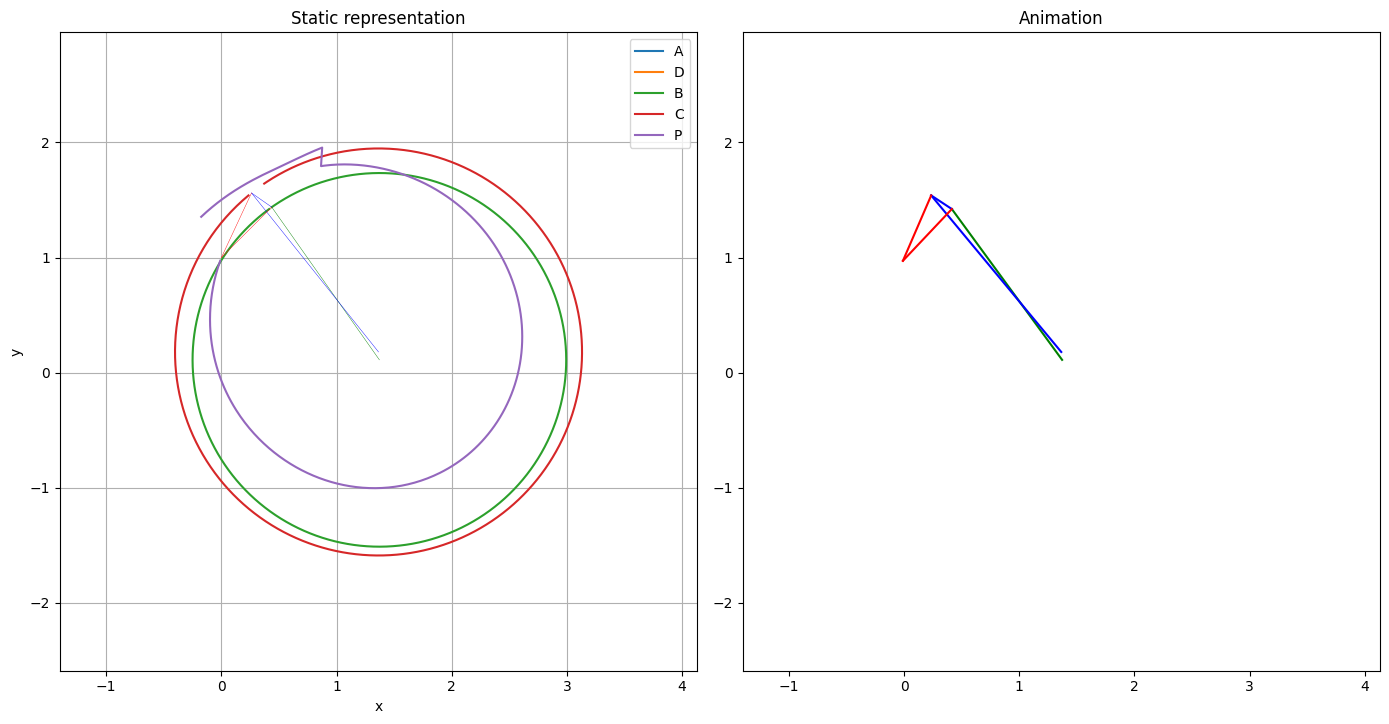

In [13]:
# Show the best synthesis candidate (already simulated)
anim = synth_ens.show(idx=0)
plt.show()

### Interactive Plotly view

`Ensemble.plot_plotly(idx)` creates an interactive diagram:

In [14]:
fig = synth_ens.plot_plotly(idx=0, title="Best synthesis candidate")
fig.show()

### SVG export

`Ensemble.save_svg(path, idx)` exports publication-quality SVGs:

In [15]:
import os
import tempfile

with tempfile.NamedTemporaryFile(suffix=".svg", delete=False) as f:
    svg_path = f.name

synth_ens.save_svg(svg_path, idx=0)
print(f"SVG saved: {os.path.getsize(svg_path):,} bytes")
os.unlink(svg_path)

SVG saved: 74,642 bytes


### Using `Member.to_loci()` directly

If you need to use the low-level visualizer functions directly
(e.g., `plot_static_linkage`), `Member.to_loci()` converts the
trajectory ndarray to the tuple format the visualizer expects:

loci: 360 frames, 5 joints per frame


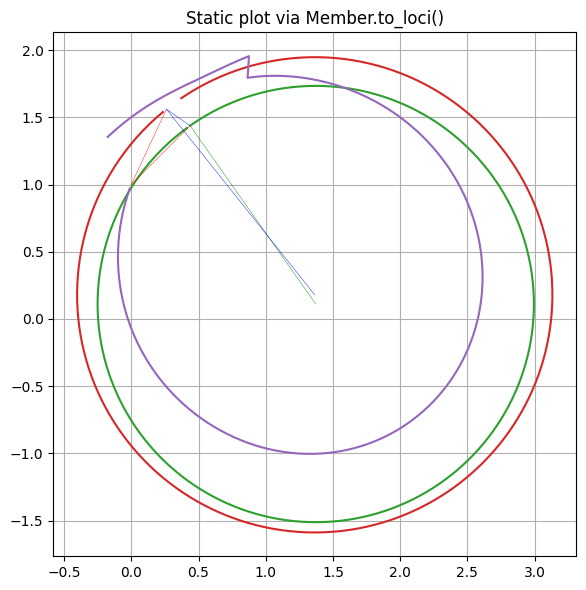

In [16]:
from pylinkage.visualizer import plot_static_linkage

member = synth_ens[0]
loci = member.to_loci()
print(f"loci: {len(loci)} frames, {len(loci[0])} joints per frame")

fig, ax = plt.subplots(figsize=(8, 6))
plot_static_linkage(synth_ens.linkage, ax, loci)
ax.set_title("Static plot via Member.to_loci()")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Part D: Population — grouping different topologies

A `Population` holds multiple `Ensemble` objects, one per topology.
This is useful when you want to compare fundamentally different mechanisms
(e.g., results from different synthesis problems, or optimization vs synthesis).

In [17]:
from pylinkage.population import Population

# Run synthesis with different precision points to get diverse mechanisms
result_a = path_generation([(0, 1), (1, 2), (2, 1.5)])
result_b = path_generation([(0, 0.5), (2, 1), (3, 0)])

# Combine into a Population
pop = Population(ensembles={
    "upward_arc": result_a.ensemble,
    "flat_reach": result_b.ensemble,
})
print(pop)
print(f"Total members: {len(pop)}")

Population(upward_arc: 10 members, flat_reach: 10 members)
Total members: 20


In [18]:
# Simulate all topologies at once
pop.simulate_all(iterations=360)

# Rank across the entire population by crank length
best_overall = pop.top(5, key="crank_length", ascending=True)
print("Top 5 most compact mechanisms across both topologies:")
for i, m in enumerate(best_overall):
    print(f"  #{i}: crank={m.scores['crank_length']:.3f}  "
          f"rocker={m.scores['rocker_length']:.3f}")

Top 5 most compact mechanisms across both topologies:
  #0: crank=0.986  rocker=1.162
  #1: crank=0.986  rocker=1.232
  #2: crank=1.149  rocker=1.322
  #3: crank=1.149  rocker=83.832
  #4: crank=1.149  rocker=2.066


In [ ]:
# Compare coupler curves from both topology groups with best mechanism drawn
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

link_pairs = [(0, 2), (2, 3), (3, 1)]  # A-B, B-C, C-D
link_colors_mech = ['#2E86AB', '#A23B72', '#F18F01']

for ax, (label, ens) in zip([ax1, ax2], pop.topologies.items(), strict=False):
    colors = plt.cm.tab10(np.linspace(0, 1, len(ens)))
    for i, member in enumerate(ens):
        traj = member.trajectory
        px = traj[:, COUPLER_P_IDX, 0]
        py = traj[:, COUPLER_P_IDX, 1]
        if np.isnan(px).any():
            continue
        ax.plot(px, py, color=colors[i], linewidth=1.2, alpha=0.7)

    # Draw the best member's mechanism at initial frame
    best_traj = ens[0].trajectory
    if not np.isnan(best_traj[0]).any():
        for (i, j), color in zip(link_pairs, link_colors_mech):
            ax.plot([best_traj[0, i, 0], best_traj[0, j, 0]],
                    [best_traj[0, i, 1], best_traj[0, j, 1]],
                    '-o', color=color, linewidth=2.5, markersize=5)
        ax.plot(best_traj[0, 0, 0], best_traj[0, 0, 1], 'ks', markersize=8, zorder=5)
        ax.plot(best_traj[0, 1, 0], best_traj[0, 1, 1], 'ks', markersize=8, zorder=5)

    ax.set_title(f'"{label}" ({len(ens)} candidates)')
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.suptitle("Population: two topology groups (best mechanism drawn)", fontsize=14)
plt.tight_layout()
plt.show()

## Summary

| Abstraction | What it holds | Key methods |
|---|---|---|
| **`Member`** | One mechanism: dimensions, scores, trajectory | `.score`, `.to_loci()`, `.to_agent()` |
| **`Ensemble`** | N variants of one topology | `.simulate()`, `.rank()`, `.top()`, `.filter()`, `.show()`, `.plot_plotly()`, `.save_svg()` |
| **`Population`** | Multiple topologies (dict of Ensembles) | `.simulate_all()`, `.rank()`, `.top()`, `.topologies` |

**Data flow:**

```
Optimization ──→ Ensemble ──→ simulate() ──→ rank/filter ──→ show()/plot_plotly()
Synthesis ──→ result.ensemble ──→ ...same...
Multi-topology ──→ Population.from_topology_solutions() ──→ simulate_all() ──→ top()
```

The core idea: **one topology + N parameter sets = `Ensemble`** (fast, vectorized),
**multiple topologies = `Population`** (heterogeneous, groups of Ensembles).